# XGBoost Embedding Baseline Model

This notebook builds an XGBoost baseline model for classifying which social media platform a post belongs to using `all-MiniLM-L6-v2` sentence embeddings.

## Goals
- load the final train, validation, test splits processed and saved from the create_datasets notebook
- encode post text with `all-MiniLM-L6-v2` sentence embeddings
- train an XGBoost classifier for multiclass platform prediction
- explicitly exclude non-text metadata features
- use GPU for embeddings and XGBoost training
- evaluate performance on validation and test sets


In [5]:
%pip install polars pyarrow pandas matplotlib scikit-learn scipy xgboost sentence-transformers torch


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from pathlib import Path
from time import perf_counter

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import xgboost as xgb

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)

polars.config.Config

## Paths

In [7]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "train_210k.parquet"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "val_45k.parquet"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "test_45k.parquet"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH, TRAIN_PATH.exists())
print(VAL_PATH, VAL_PATH.exists())
print(TEST_PATH, TEST_PATH.exists())

/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/train_210k.parquet True
/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/val_45k.parquet True
/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/test_45k.parquet True


## Load train, validation, test data

In [8]:
train_df = pl.read_parquet(TRAIN_PATH)
val_df = pl.read_parquet(VAL_PATH)
test_df = pl.read_parquet(TEST_PATH)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(209999, 18) (45000, 18) (45001, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],f64,f64,…,i8,str,f64,str,f64,f64,str
"""hackernews""","""4380112""","""beagle3""","""> the license terms are more r…",2012-08-14 05:56:40,null,null,…,8,"""2012-08""",0.0,null,null,null,"""4380100"""
"""hackernews""","""13775458""","""simplehuman""","""You read these articles too cl…",2017-03-02 11:39:10,null,null,…,3,"""2017-03""",0.0,null,null,null,"""13775414"""
"""hackernews""","""39727388""","""toomuchtodo""","""Like <a href=""https://www.he36…",2024-03-16 12:44:56,null,null,…,3,"""2024-03""",0.0,null,null,null,"""39726890"""
"""hackernews""","""41179214""","""I_am_uncreative""","""In the English Language, ""Amer…",2024-08-07 04:02:06,null,null,…,8,"""2024-08""",0.0,null,null,null,"""41177797"""
"""hackernews""","""12680008""","""acaciapalm""","""I used the word ""show"" not ""pr…",2016-10-10 17:46:45,null,null,…,10,"""2016-10""",0.0,null,null,null,"""12679942"""


## Quick class balance checks

In [9]:
print(train_df.group_by("platform").len().sort("platform"))
print(val_df.group_by("platform").len().sort("platform"))
print(test_df.group_by("platform").len().sort("platform"))

shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 70000 │
│ reddit     ┆ 70000 │
│ twitter    ┆ 69999 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 15000 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 15000 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15001 │
└────────────┴───────┘


## Feature policy

This notebook uses only the post text.

We explicitly do not use features like created_at, year, month, year_month, post_id, author, community, likes, retweets, replies, quotes, score, parent_id, or other metadata because they might encode platform-specific artifacts instead of classifying from the language of the post itself.

## Change to pandas for modeling

In [10]:
train_pdf = train_df.to_pandas()
val_pdf = val_df.to_pandas()
test_pdf = test_df.to_pandas()

print(train_pdf.columns.tolist())

['platform', 'post_id', 'author', 'text', 'created_at', 'likes', 'retweets', 'replies', 'quotes', 'text_len', 'year', 'month', 'year_month', 'score', 'community', 'num_comments', 'upvote_ratio', 'parent_id']


## Check GPU setup

This notebook expects CUDA to be available for both sentence embeddings and XGBoost training.

In [11]:
print("Torch version:", torch.__version__)
print("CUDA available in torch:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

xgb_build_info = xgb.build_info()
print("XGBoost version:", xgb.__version__)
print("XGBoost CUDA enabled:", bool(xgb_build_info.get("USE_CUDA", False)))

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available to PyTorch. Embedding generation would fall back to CPU.")

if not bool(xgb_build_info.get("USE_CUDA", False)):
    raise RuntimeError("This XGBoost build does not report CUDA support. GPU training will not be used.")

GPU_NAME = torch.cuda.get_device_name(0)
print("Using GPU:", GPU_NAME)

Torch version: 2.11.0
CUDA available in torch: False
CUDA device count: 0
XGBoost version: 3.2.0
XGBoost CUDA enabled: False


RuntimeError: CUDA is not available to PyTorch. Embedding generation would fall back to CPU.

## Encode text with `all-MiniLM-L6-v2`

In [ ]:
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DEVICE = "cuda"
BATCH_SIZE = 256

X_train_text = train_pdf["text"].astype(str).tolist()
X_val_text = val_pdf["text"].astype(str).tolist()
X_test_text = test_pdf["text"].astype(str).tolist()

print("Loading embedding model...")
t0 = perf_counter()
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=EMBEDDING_DEVICE)
t1 = perf_counter()
print(f"Embedding model loaded in {t1 - t0:.2f} seconds")
print("Embedding device:", embedding_model.device)

print("Encoding train text...")
t0 = perf_counter()
X_train_embed = embedding_model.encode(
    X_train_text,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
t1 = perf_counter()
print(f"Train embeddings done in {t1 - t0:.2f} seconds")

print("Encoding validation text...")
t0 = perf_counter()
X_val_embed = embedding_model.encode(
    X_val_text,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
t1 = perf_counter()
print(f"Validation embeddings done in {t1 - t0:.2f} seconds")

print("Encoding test text...")
t0 = perf_counter()
X_test_embed = embedding_model.encode(
    X_test_text,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
t1 = perf_counter()
print(f"Test embeddings done in {t1 - t0:.2f} seconds")

print("Embedding shapes:", X_train_embed.shape, X_val_embed.shape, X_test_embed.shape)

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Train embeddings done in 162.03 seconds
Encoding validation text...


Batches:   0%|          | 0/176 [00:00<?, ?it/s]

Validation embeddings done in 34.46 seconds
Encoding test text...


Batches:   0%|          | 0/176 [00:00<?, ?it/s]

Test embeddings done in 35.11 seconds
Embedding shapes: (209999, 384) (45000, 384) (45001, 384)


## Encode labels for XGBoost

In [ ]:
y_train = train_pdf["platform"]
y_val = val_pdf["platform"]
y_test = test_pdf["platform"]

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['hackernews' 'reddit' 'twitter']


## Train XGBoost and evaluate

In [ ]:
t0 = perf_counter()

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_embed,
    y_train_encoded,
    eval_set=[(X_val_embed, y_val_encoded)],
    verbose=False,
)

t1 = perf_counter()
print(f"Finished training in {t1 - t0:.2f} seconds")
print("Configured device:", xgb_model.get_xgb_params().get("device"))

val_pred_encoded = xgb_model.predict(X_val_embed)
test_pred_encoded = xgb_model.predict(X_test_embed)

val_pred = label_encoder.inverse_transform(val_pred_encoded)
test_pred = label_encoder.inverse_transform(test_pred_encoded)

val_accuracy = accuracy_score(y_val, val_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Validation accuracy:", val_accuracy)
print(classification_report(y_val, val_pred))

print("Test accuracy:", test_accuracy)
print(classification_report(y_test, test_pred))

Finished training in 51.82 seconds
Configured device: cuda
Validation accuracy: 0.8942
              precision    recall  f1-score   support

  hackernews       0.88      0.93      0.90     15000
      reddit       0.89      0.87      0.88     15000
     twitter       0.91      0.88      0.90     15000

    accuracy                           0.89     45000
   macro avg       0.89      0.89      0.89     45000
weighted avg       0.89      0.89      0.89     45000

Test accuracy: 0.8946467856269861
              precision    recall  f1-score   support

  hackernews       0.88      0.93      0.90     15000
      reddit       0.89      0.88      0.88     15000
     twitter       0.92      0.88      0.90     15001

    accuracy                           0.89     45001
   macro avg       0.90      0.89      0.89     45001
weighted avg       0.90      0.89      0.89     45001



## Confusion matrix on the test set

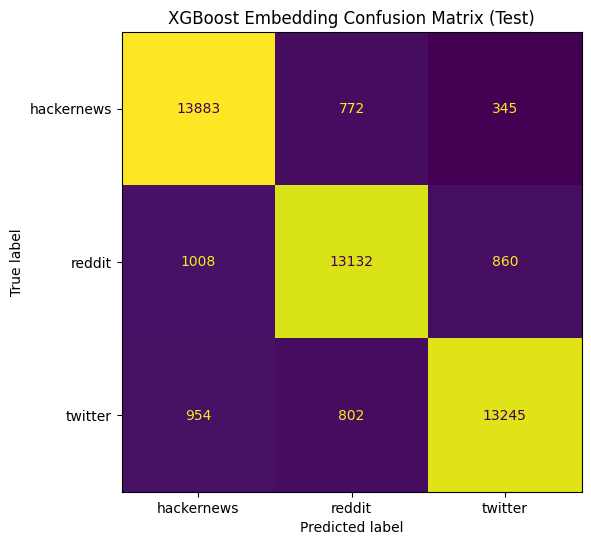

In [ ]:
labels = list(label_encoder.classes_)

cm = confusion_matrix(y_test, test_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("XGBoost Embedding Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "xgboost_embedding_confusion_matrix.png", dpi=150)
plt.show()

## Most important embedding dimensions

In [ ]:
importance_df = pd.DataFrame({
    "embedding_dim": range(X_train_embed.shape[1]),
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.head(20)

,embedding_dim,importance
11,11,0.041700
250,250,0.037482
176,176,0.031687
370,370,0.017142
223,223,0.016526
319,319,0.015138
142,142,0.014144
231,231,0.012530
294,294,0.011820
154,154,0.011502


In [ ]:
# XGBoost dashboard export intentionally omitted for now.

NameError: name 'val_accuracy' is not defined